# 02 · Pré-processamento, novas variáveis e Information Value

No [notebook de EDA](01_eda.ipynb) encontrei vários problemas na base: códigos de sistema disfarçados de contagem de atraso, um `debt_ratio` que muda de significado quando a renda falta e alguns valores impossíveis. Aqui transformo esses achados em código.

A limpeza e as variáveis novas ficam em `src/credit_scoring/features.py`, e o cálculo de WoE/IV em `src/credit_scoring/woe.py`. As duas partes têm testes em `tests/`. Deixar isso fora do notebook garante que treino, validação, teste e qualquer proposta nova passem exatamente pela mesma transformação.

Depois da limpeza, divido a base em treino, validação e teste e calculo o Information Value de cada variável **usando só o treino**.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from credit_scoring.data import PROCESSED_DIR, TARGET, load_raw, split_train_val_test
from credit_scoring.features import FEATURES, build_features
from credit_scoring.plotting import BLUE, GRAY, ORANGE, savefig, set_style
from credit_scoring.reporting import update_metrics
from credit_scoring.woe import MISSING, WoEEncoder, iv_strength

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

raw = load_raw()
df = build_features(raw)
print(f"{len(df):,} linhas | {len(FEATURES)} variáveis candidatas")

150,000 linhas | 15 variáveis candidatas


## 1. O que a limpeza mudou

Vale conferir se cada regra pegou exatamente o que deveria. A tabela abaixo compara a quantidade de valores faltantes antes e depois da limpeza.

In [2]:
raw_cols = [c for c in raw.columns if c != TARGET]
pd.DataFrame({
    "faltantes_antes": raw[raw_cols].isna().sum(),
    "faltantes_depois": df[raw_cols].isna().sum(),
}).assign(diferença=lambda t: t["faltantes_depois"] - t["faltantes_antes"]).query("faltantes_depois > 0")

,faltantes_antes,faltantes_depois,diferença
age,0,1,1
late_30_59,0,269,269
debt_ratio,0,31970,31970
monthly_income,29731,31970,2239
late_90,0,269,269
late_60_89,0,269,269
dependents,3924,3924,0


- As três colunas de atraso ganharam os mesmos faltantes: são as linhas com código 96/98, agora marcadas em `late_special_code`.
- `monthly_income` ganhou alguns faltantes a mais que no dado bruto porque renda 0 ou 1 também passou a contar como "não informada". Conferi antes: nesses casos o `debt_ratio` fica na casa das centenas ou milhares, igualzinho a quem não informou renda nenhuma.
- `debt_ratio` fica faltante sempre que a renda falta, porque ali ele não é uma razão.
- `age` perdeu o único caso com idade 0.

## 2. As variáveis novas

| Variável | O que é | Por quê |
|---|---|---|
| `income_missing` | 1 se a renda não foi informada (ou é 0/1) | O faltante não é aleatório: esse grupo tem risco diferente |
| `late_special_code` | 1 se as colunas de atraso tinham 96/98 | Isola um grupo pequeno e muito arriscado |
| `total_late` | soma dos três tipos de atraso | Resume o histórico de atraso numa variável só |
| `monthly_debt` | valor da dívida mensal | Recupera a informação do `debt_ratio` para quem não tem renda |
| `income_per_person` | renda / (dependentes + 1) | A mesma renda pesa diferente para uma pessoa sozinha e para uma família de cinco |

`monthly_debt` é a que eu acho mais interessante. Quando a renda existe, a dívida mensal é `debt_ratio × renda`. Quando não existe, o próprio `debt_ratio` já é a dívida. Com isso, a mesma grandeza fica comparável para todo mundo, em vez de jogar fora a informação de 20% da base.

In [3]:
new_cols = ["income_missing", "late_special_code", "total_late", "monthly_debt", "income_per_person"]
display(df[new_cols].describe(percentiles=[.5, .9, .99]).T)

display(
    df.groupby("income_missing")
      .agg(n=(TARGET, "size"), taxa_default=(TARGET, "mean"), monthly_debt_mediana=("monthly_debt", "median"))
)

,count,mean,std,min,50%,90%,99%,max
income_missing,"150,000.000",0.213,0.410,0.000,0.000,1.000,1.000,1.000
late_special_code,"150,000.000",0.002,0.042,0.000,0.000,0.000,0.000,1.000
total_late,"149,731.000",0.401,1.102,0.000,0.000,1.000,5.000,19.000
monthly_debt,"150,000.000","2,046.817","4,215.791",0.000,"1,546.660","4,280.924","9,184.495","478,450.559"
income_per_person,"118,030.000","4,594.771","8,945.948",0.667,"3,400.000","8,900.000","18,750.000","1,794,060.000"


,n,taxa_default,monthly_debt_mediana
income_missing,,,
0,118030,0.070,"1,656.816"
1,31970,0.055,"1,129.500"


A dívida mensal mediana de quem não informou renda ficou na mesma ordem de grandeza da de quem informou. Isso reforça a hipótese de que, sem renda, o `debt_ratio` guardava o valor da dívida.

## 3. Divisão da base

Uso 70% para treino, 15% para validação e 15% para teste, estratificando pelo alvo para que as três partes tenham a mesma taxa de default. A validação serve para comparar modelos e escolher o ponto de corte. O teste fica guardado até o fim e só é usado uma vez, para o número final.

In [4]:
train, val, test = split_train_val_test(df)

split_summary = pd.DataFrame({
    name: {"linhas": len(d), "inadimplentes": int(d[TARGET].sum()), "taxa_default": d[TARGET].mean()}
    for name, d in {"treino": train, "validação": val, "teste": test}.items()
}).T.astype({"linhas": int, "inadimplentes": int})
split_summary

,linhas,inadimplentes,taxa_default
treino,105000,7018,0.067
validação,22500,1504,0.067
teste,22500,1504,0.067


## 4. Weight of Evidence e Information Value

Para cada variável, divido os valores em faixas e comparo a proporção de bons e maus pagadores em cada uma:

$$\text{WoE}_i = \ln\left(\frac{\%\text{bons}_i}{\%\text{maus}_i}\right) \qquad \text{IV} = \sum_i (\%\text{bons}_i - \%\text{maus}_i) \times \text{WoE}_i$$

WoE positivo quer dizer que a faixa tem menos risco que a média, e negativo, mais risco. O IV resume o quanto a variável separa os dois grupos. Os faltantes sempre ganham uma faixa própria, o que resolve de uma vez os códigos 96/98 e a renda não informada.

As faixas são automáticas por enquanto: cerca de 10 faixas com a mesma quantidade de pessoas, nunca dividindo um mesmo valor em duas faixas e com pelo menos 1% da base em cada uma. Isso é o *fine classing*. No notebook da regressão logística eu agrupo essas faixas à mão (*coarse classing*) para deixar o WoE monotônico onde fizer sentido.

Tudo é calculado **só no treino**. Se as faixas e os WoE fossem calculados na base inteira, a informação da validação e do teste vazaria para o modelo.

In [5]:
encoder = WoEEncoder().fit(train[FEATURES], train[TARGET])

iv = encoder.iv_.to_frame()
iv["força"] = iv["iv"].map(iv_strength)
iv["n_faixas"] = [len(encoder.edges_[f]) + 1 for f in iv.index]
iv

,iv,força,n_faixas
total_late,1.340,muito forte (checar vazamento),3
revolving_util,1.118,muito forte (checar vazamento),10
late_90,0.842,muito forte (checar vazamento),2
late_30_59,0.726,muito forte (checar vazamento),3
late_60_89,0.574,muito forte (checar vazamento),2
age,0.245,médio,9
income_per_person,0.114,médio,10
debt_ratio,0.084,fraco,10
monthly_income,0.078,fraco,10
open_credit_lines,0.072,fraco,8


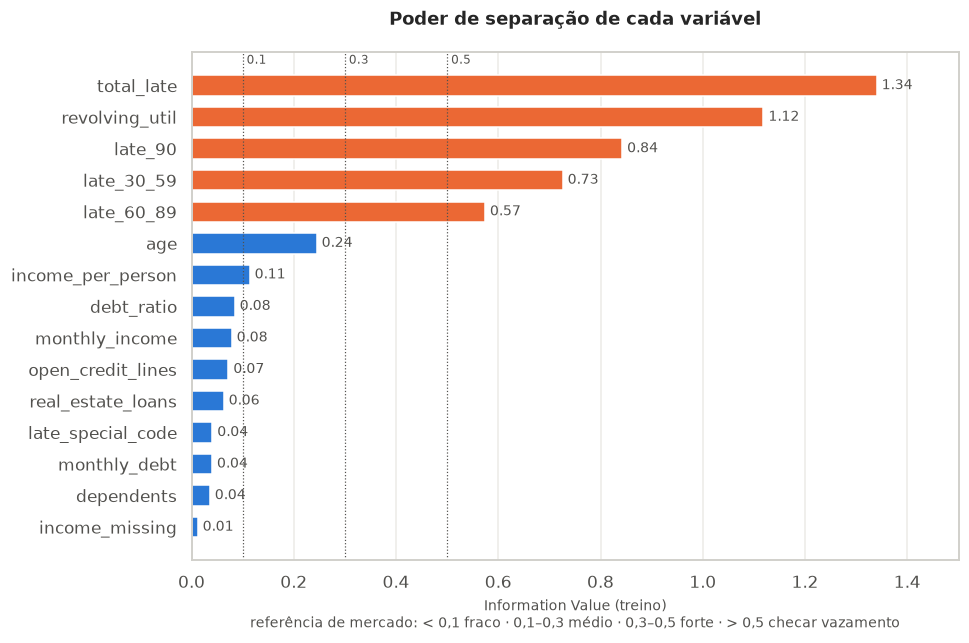

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
iv_sorted = iv["iv"].sort_values()
colors = [ORANGE if v >= 0.5 else BLUE for v in iv_sorted]
ax.barh(iv_sorted.index, iv_sorted.values, color=colors, height=0.65)
for i, v in enumerate(iv_sorted.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9, color=GRAY)
for x in [0.1, 0.3, 0.5]:
    ax.axvline(x, color=GRAY, lw=0.8, ls=":")
    ax.text(x, len(iv_sorted) - 0.4, f" {x:g}", fontsize=8, color=GRAY, va="bottom")
ax.set_xlabel("Information Value (treino)\nreferência de mercado: < 0,1 fraco · 0,1–0,3 médio · 0,3–0,5 forte · > 0,5 checar vazamento",
              fontsize=9)
ax.set_title("Poder de separação de cada variável", pad=18)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, iv_sorted.max() * 1.12)
savefig(fig, "features_iv")
plt.show()

Cinco variáveis passam de 0,5 (em laranja): o total de atrasos, a utilização do rotativo e as três colunas de atraso. Pela regra de bolso do mercado, IV acima de 0,5 é "bom demais para ser verdade" e merece uma checagem de vazamento, ou seja, de a variável conter informação do próprio alvo.

Neste caso não acho que seja vazamento, por três motivos:

1. As variáveis de atraso descrevem o **passado** do cliente (últimos dois anos), enquanto o alvo mede um atraso de 90+ dias nos **dois anos seguintes**. São janelas de tempo diferentes.
2. Faz todo sentido de negócio: quem já atrasou e quem está com o limite estourado são justamente os perfis que mais inadimplem. É o que qualquer bureau de crédito usa como sinal principal.
3. Esses valores são conhecidos para esta base. Quem trabalhou com o Give Me Some Credit costuma encontrar IVs nessa faixa para essas mesmas variáveis.

Mesmo assim, vale uma checagem objetiva: se o IV fosse fruto de sobreajuste às faixas do treino, ele cairia bastante na validação. Abaixo aplico as mesmas faixas do treino na validação e comparo.

In [7]:
val_encoder = WoEEncoder(edges=encoder.edges_).fit(val[FEATURES], val[TARGET])
stability = pd.DataFrame({"iv_treino": encoder.iv_, "iv_validação": val_encoder.iv_})
stability["diferença_%"] = (stability["iv_validação"] / stability["iv_treino"] - 1) * 100
stability.sort_values("iv_treino", ascending=False)

,iv_treino,iv_validação,diferença_%
total_late,1.340,1.408,5.079
revolving_util,1.118,1.067,-4.611
late_90,0.842,0.831,-1.328
late_30_59,0.726,0.749,3.219
late_60_89,0.574,0.571,-0.434
age,0.245,0.264,8.022
income_per_person,0.114,0.110,-3.344
debt_ratio,0.084,0.092,9.570
monthly_income,0.078,0.093,18.847
open_credit_lines,0.072,0.063,-11.957


Nas cinco variáveis mais fortes, o IV da validação fica a menos de 10% do IV do treino. O poder de separação se sustenta fora da amostra, então não é um artefato das faixas.

Nas variáveis fracas a oscilação relativa é maior, o que é esperado: com IV perto de 0,05, qualquer ruído vira uma variação percentual grande. A que mais chama atenção é `real_estate_loans`, que perde boa parte do IV na validação. É uma candidata a sair do modelo, ou pelo menos a ter as faixas simplificadas.

Uma observação: `total_late` tem o maior IV, mas carrega praticamente a mesma informação das três colunas de atraso. No modelo linear vou ter que escolher entre usar o total ou as colunas separadas, para não colocar informação redundante (e coeficientes instáveis) no modelo.

## 5. O WoE de cada faixa

O IV diz o quanto a variável separa bons e maus. O gráfico de WoE mostra **como** separa: se o risco sobe de forma consistente, se tem forma de U, se o faltante é muito diferente do resto.

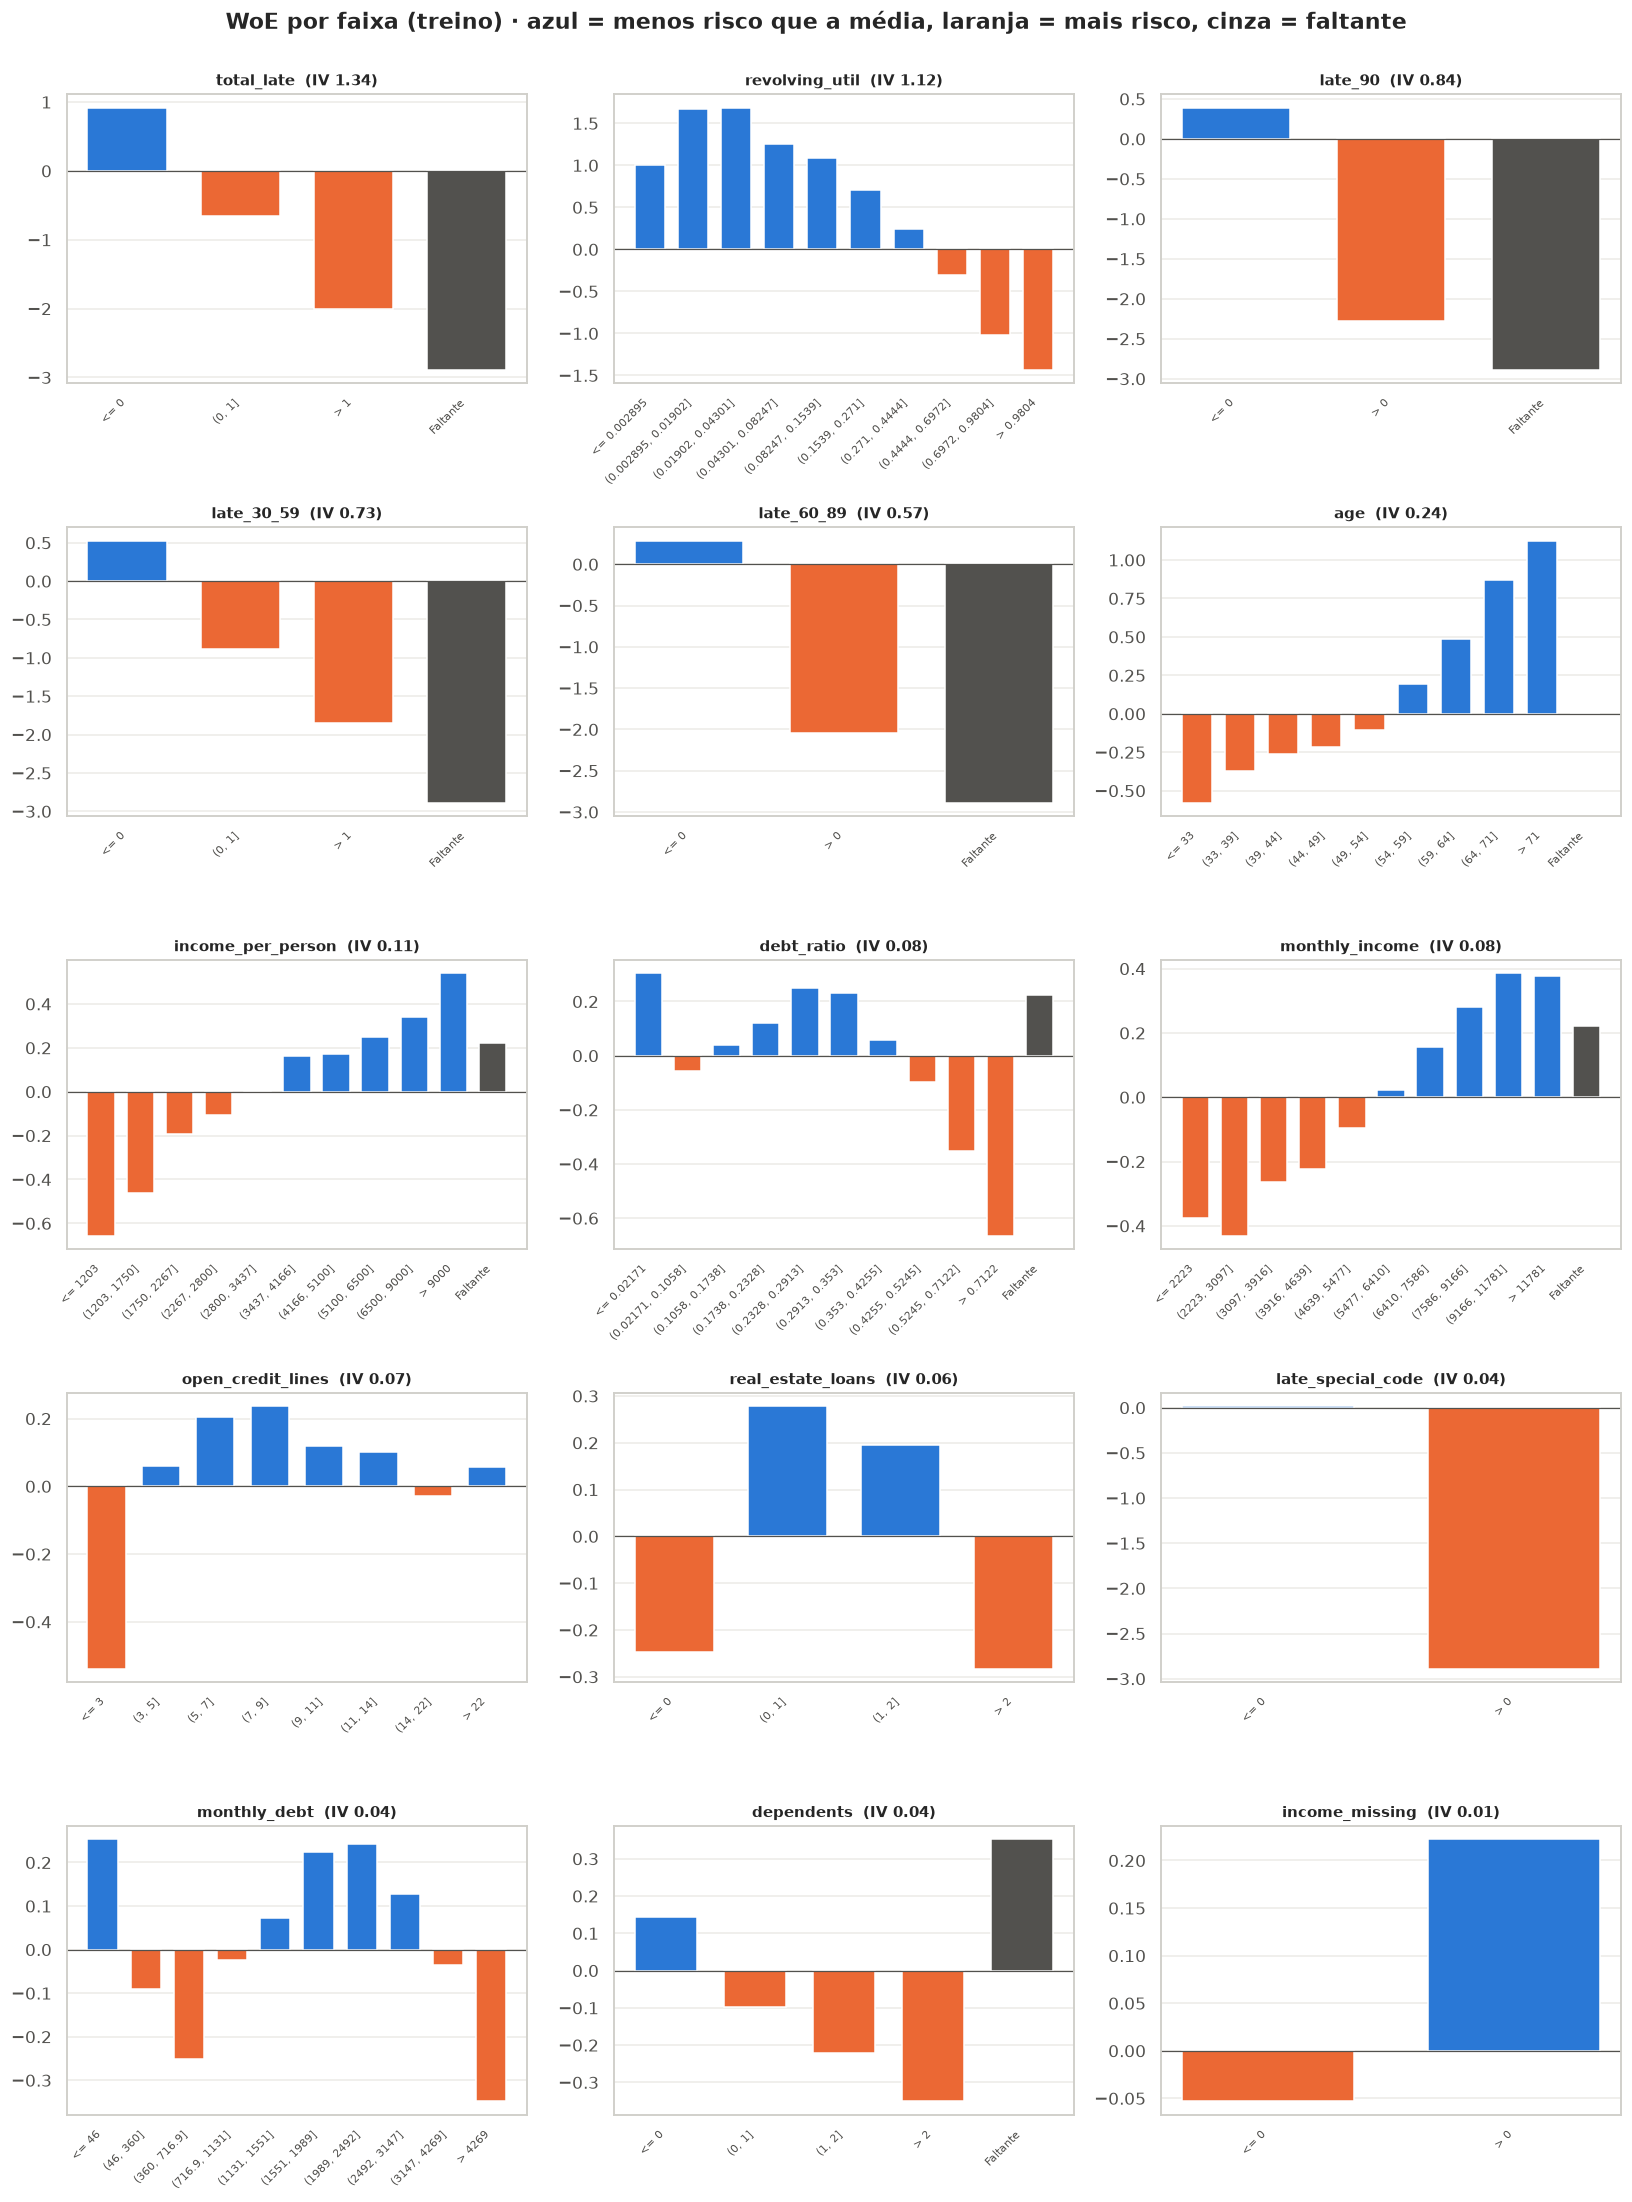

In [8]:
def plot_woe(ax, table, title):
    colors = [GRAY if b == MISSING else (BLUE if w >= 0 else ORANGE) for b, w in zip(table["bin"], table["woe"])]
    ax.bar(range(len(table)), table["woe"], color=colors, width=0.7)
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels(table["bin"].astype(str), rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{title}  (IV {table['iv'].sum():.2f})", fontsize=10)
    ax.grid(axis="x", visible=False)

order = encoder.iv_.index
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for ax, col in zip(axes.flat, order):
    plot_woe(ax, encoder.tables_[col], col)
fig.suptitle("WoE por faixa (treino) · azul = menos risco que a média, laranja = mais risco, cinza = faltante",
             fontweight="bold", y=1.0)
fig.tight_layout()
savefig(fig, "features_woe")
plt.show()

Algumas coisas que aparecem aqui e vão ser importantes no modelo:

As variáveis de atraso têm um degrau enorme entre "nenhum atraso" e "algum atraso". Com o binning automático, o 1 e o 2+ acabam na mesma faixa em algumas delas, o que dá para refinar no *coarse classing*.

`revolving_util` tem um padrão curioso no começo: quem usa **zero** do limite é um pouco mais arriscado do que quem usa um pouquinho. Provavelmente é gente com pouco histórico ou que teve o crédito cortado. Depois disso, o risco sobe sem parar até o limite estourado.

A idade é bem comportada: quanto mais velho, menor o risco, faixa após faixa. E, confirmando o EDA, não informar renda ou dependentes aparece como risco **menor** que a média (WoE positivo no faltante). `debt_ratio`, `open_credit_lines` e `real_estate_loans` têm forma de U e vão precisar de agrupamento manual para funcionar bem num modelo linear.

## 6. Salvando as bases

As três bases vão para `data/processed/` em parquet, já com as variáveis novas. Os tamanhos e as taxas de default vão para `reports/metrics.json`, que é a única fonte dos números que vão aparecer no README.

In [9]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
for name, d in {"train": train, "val": val, "test": test}.items():
    d.to_parquet(PROCESSED_DIR / f"{name}.parquet")

metrics = update_metrics("data", {
    "n_rows": int(len(df)),
    "default_rate": round(float(df[TARGET].mean()), 4),
    "splits": {
        name: {"n_rows": int(len(d)), "default_rate": round(float(d[TARGET].mean()), 4)}
        for name, d in {"train": train, "val": val, "test": test}.items()
    },
    "iv_train": {k: round(float(v), 4) for k, v in encoder.iv_.items()},
})
print(json.dumps(metrics["data"]["splits"], indent=2))
print(sorted(p.name for p in PROCESSED_DIR.glob("*.parquet")))

{
  "train": {
    "n_rows": 105000,
    "default_rate": 0.0668
  },
  "val": {
    "n_rows": 22500,
    "default_rate": 0.0668
  },
  "test": {
    "n_rows": 22500,
    "default_rate": 0.0668
  }
}
['test.parquet', 'train.parquet', 'val.parquet']
